
Problem Statement

Customer Lifetime Value represents a customer’s value to a company over a period of time. It’s a competitive market for insurance companies in 2019, and insurance premium isn’t the only determining factor in a customer’s decisions. CLV is a customer-centric metric, and a powerful base to build upon to retain valuable customers, increase revenue from less valuable customers, and improve the customer experience overall.

Auto Insurance company is facing issues in retaining its customers and wants to advertise promotional offers for its loyal customers. They are considering CLV as a parameter to classify loyal customers.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [ ]:
import pandas as pd
df=pd.read_csv("/content/AutoInsurance.csv.zip")
df.head()

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,3/2/2011,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


In [ ]:
print("The number of rows:",df.shape[0])
print("The number of columns:",df.shape[1])

The number of rows: 9134
The number of columns: 24


In [ ]:
df.rename(columns={'Customer Lifetime Value':'CLV'},inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   object 
 1   State                          9134 non-null   object 
 2   CLV                            9134 non-null   float64
 3   Response                       9134 non-null   object 
 4   Coverage                       9134 non-null   object 
 5   Education                      9134 non-null   object 
 6   Effective To Date              9134 non-null   object 
 7   EmploymentStatus               9134 non-null   object 
 8   Gender                         9134 non-null   object 
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   object 
 11  Marital Status                 9134 non-null   object 
 12  Monthly Premium Auto           9134 non-null   i

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [129]:
from sklearn.preprocessing import LabelEncoder
# 2. Preprocessing & Feature Engineering
# Mapping Insurance columns to LTV concepts:
# Frequency -> Number of Policies
# Recency -> Months Since Last Claim
# AOV -> Monthly Premium Auto

# Encoding categorical variables
le = LabelEncoder()
categorical_features = df.select_dtypes(include=['object']).columns
for col in categorical_features:
    if col != 'Customer': # Skip the ID column
        df[col] = le.fit_transform(df[col].astype(str))

# Select features for the model
features = ['Number of Policies', 'Months Since Last Claim', 'Monthly Premium Auto',
            'Income', 'Education', 'EmploymentStatus', 'Marital Status', 'Vehicle Class']
target = 'CLV'

X = df[features]
y = df[target]

In [130]:
# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Regression Model (Random Forest)
# Note: You can swap this for xgb.XGBRegressor() if xgboost is installed
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [131]:
# 5. Model Validation
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Model Performance ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-Squared Score: {r2:.2f}")

# 6. Customer Segmentation based on predicted LTV
df['Predicted_LTV'] = model.predict(X)

# Define segments using quantiles
low_threshold = df['Predicted_LTV'].quantile(0.33)
high_threshold = df['Predicted_LTV'].quantile(0.66)

def get_segment(val):
    if val <= low_threshold: return 'Low Value'
    if val <= high_threshold: return 'Medium Value'
    return 'High Value'

df['LTV_Segment'] = df['Predicted_LTV'].apply(get_segment)


--- Model Performance ---
Mean Absolute Error (MAE): $1570.39
Root Mean Squared Error (RMSE): $4100.40
R-Squared Score: 0.67


In [132]:
# 7. Results Overview
print("\n--- Customer Segments Sample ---")
print(df[['Customer', 'Predicted_LTV', 'LTV_Segment']].head())

# Save results for Excel Mini analysis
df.to_csv('predicted_customer_ltv.csv', index=False)


--- Customer Segments Sample ---
  Customer  Predicted_LTV   LTV_Segment
0  BU79786    2716.695865     Low Value
1  QZ44356    6673.888128  Medium Value
2  AI49188   16926.786935    High Value
3  WW63253    7706.298884  Medium Value
4  HB64268    2857.926155     Low Value


In [ ]:
numerical_cols = df.select_dtypes(include=["int64","float64"])

In [ ]:
numerical_cols.columns

Index(['CLV', 'Income', 'Monthly Premium Auto', 'Months Since Last Claim',
       'Months Since Policy Inception', 'Number of Open Complaints',
       'Number of Policies', 'Total Claim Amount'],
      dtype='object')

In [ ]:
numerical_cols = numerical_cols.drop(["Number of Policies","Number of Open Complaints"],axis=1, errors='ignore')

Summary Statistics of Numerical features

In [ ]:
numerical_cols.describe()

,CLV,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Total Claim Amount
count,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000,9134.000000
mean,8004.940475,37657.380009,93.219291,15.097000,48.064594,434.088794
std,6870.967608,30379.904734,34.407967,10.073257,27.905991,290.500092
min,1898.007675,0.000000,61.000000,0.000000,0.000000,0.099007
25%,3994.251794,0.000000,68.000000,6.000000,24.000000,272.258244
50%,5780.182197,33889.500000,83.000000,14.000000,48.000000,383.945434
75%,8962.167041,62320.000000,109.000000,23.000000,71.000000,547.514839
max,83325.381190,99981.000000,298.000000,35.000000,99.000000,2893.239678


Checking Null values

In [ ]:
df.isnull().sum()

,0
Customer,0
State,0
CLV,0
Response,0
Coverage,0
Education,0
Effective To Date,0
EmploymentStatus,0
Gender,0
Income,0


There are no Null values in dataset.

**EDA**

**Numerical Features**

**CLV - Target variable analysis**

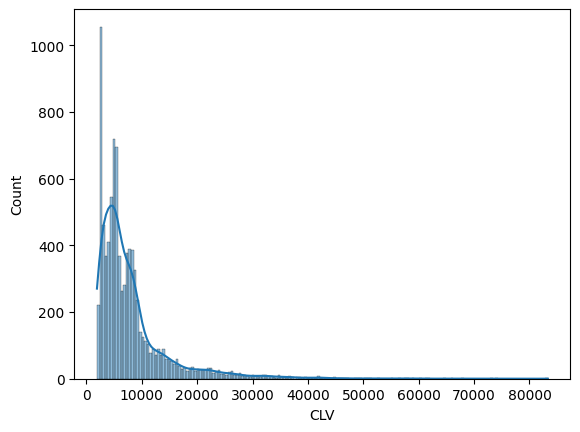

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["CLV"], kde=True)
# plt.savefig("CLV.png")
plt.show()

/tmp/ipython-input-440849046.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["CLV"])


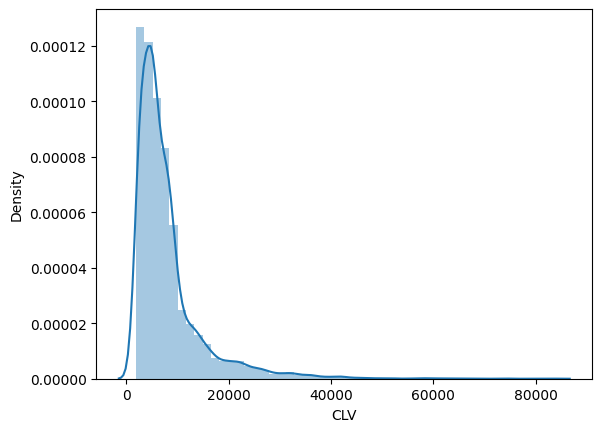

In [ ]:
sns.distplot(df["CLV"])
# plt.savefig("CLV.png")
plt.show()

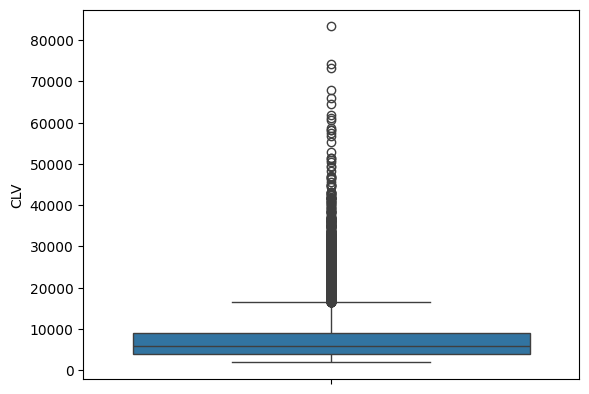

In [ ]:
sns.boxplot(df["CLV"])
plt.show()

In [ ]:
df["CLV"].skew()

np.float64(3.0322802599299847)

From the distribution and box plot we can infer that CLV is highly right skewed. There are lot of outliers in our dependent variable but we cant treat them directly because they are influential points.

**Income**

**Univariate Analysis**

/tmp/ipython-input-3289545506.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Income"])


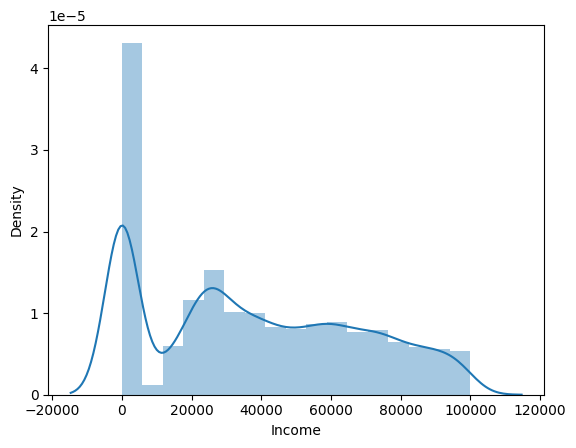

In [ ]:
sns.distplot(df["Income"])
plt.show()

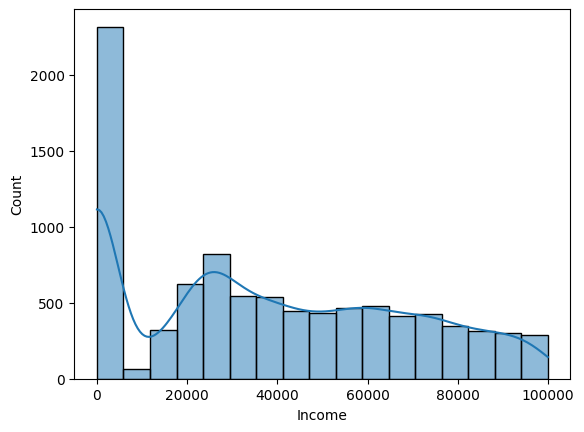

In [ ]:
sns.histplot(df["Income"], kde=True)
plt.show()

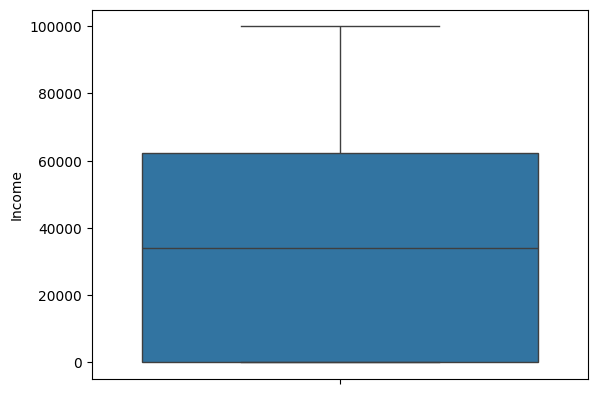

In [ ]:
sns.boxplot(df["Income"])
plt.show()

Bivariate Analysis

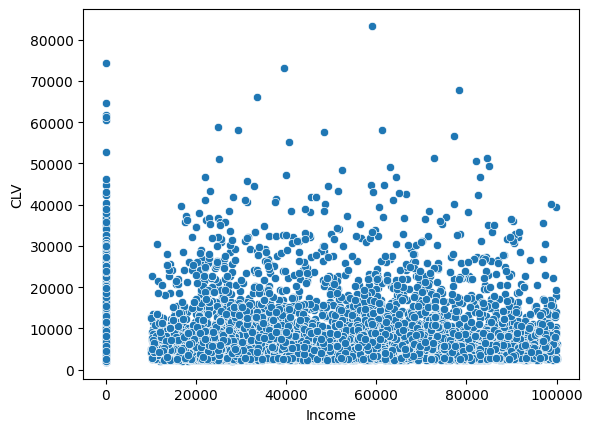

In [ ]:
sns.scatterplot(x=df["Income"], y=df["CLV"])
plt.show()

There is no linear relationship between income and CLV

**Monthly Premium Auto**

/tmp/ipython-input-1342115661.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Monthly Premium Auto"],color='c')


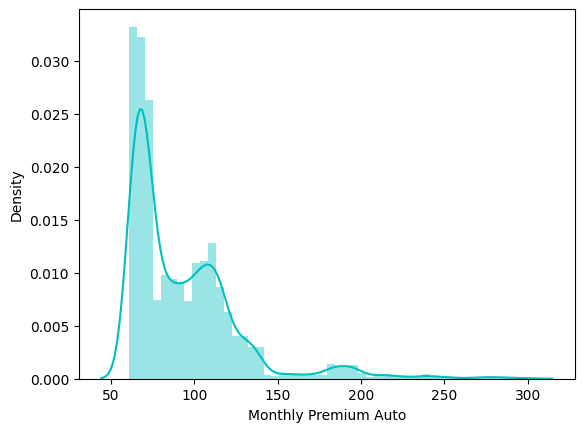

In [ ]:
sns.distplot(df["Monthly Premium Auto"],color='c')
plt.show()

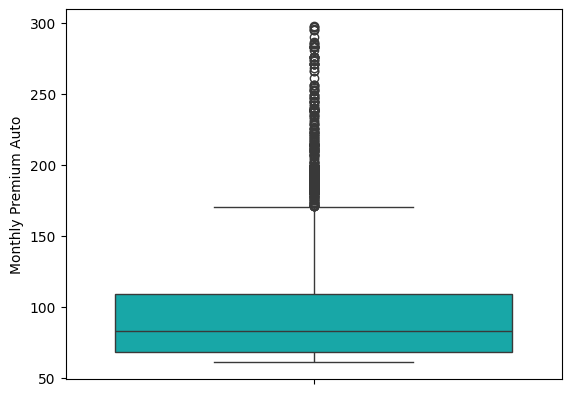

In [ ]:
sns.boxplot(df["Monthly Premium Auto"],color='c')
plt.show()

**Bivariate Analysis**

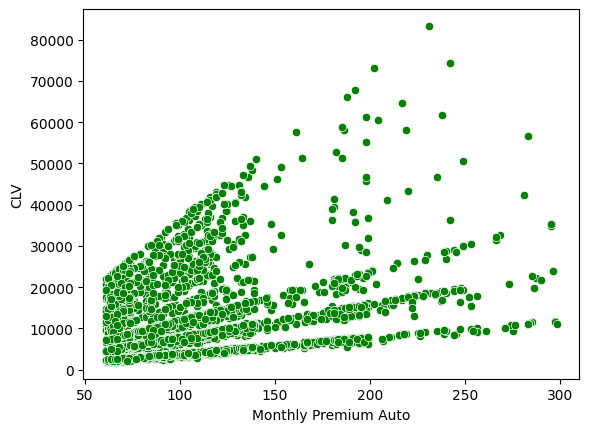

In [ ]:
sns.scatterplot(x=df["Monthly Premium Auto"], y=df["CLV"], color='g')
# plt.savefig("bi.png")
plt.show()

There is linear relationship between income and CLV

**Months Since Last Claim**

/tmp/ipython-input-3196089076.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Months Since Last Claim'])


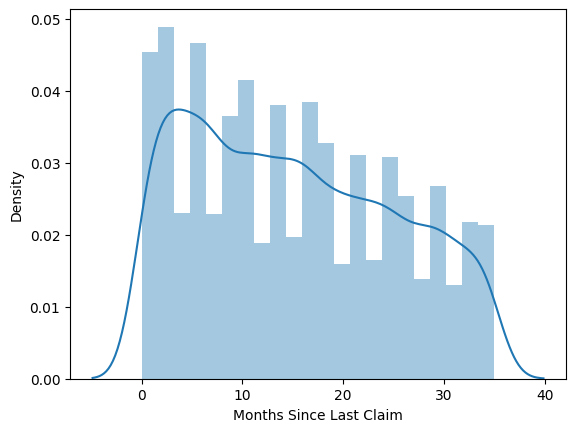

In [ ]:
sns.distplot(df['Months Since Last Claim'])
plt.show()

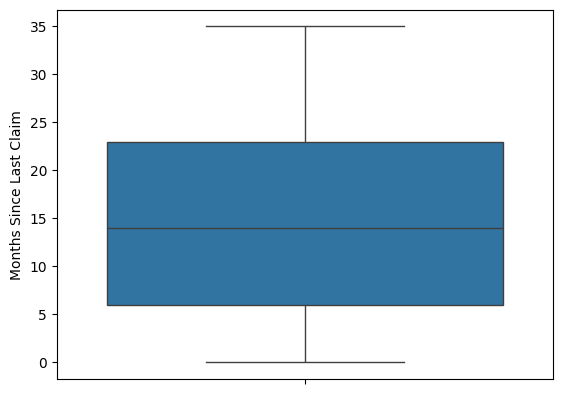

In [ ]:
sns.boxplot(df["Months Since Last Claim"])
plt.show()

**Bivariate Analysis**

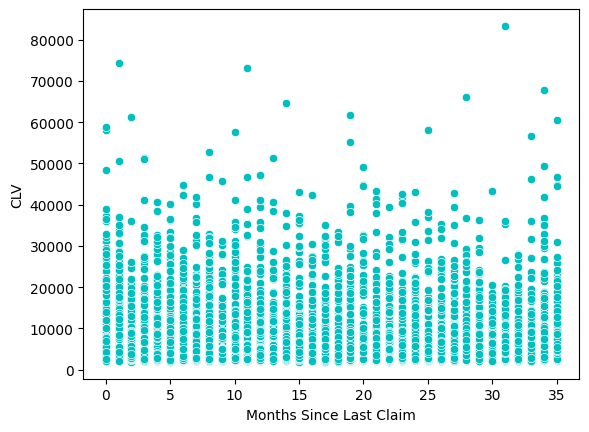

In [ ]:
sns.scatterplot(x=df["Months Since Last Claim"], y=df["CLV"], color='c')
plt.show()

There is no linear relationship

**Months Since Policy Inception**

/tmp/ipython-input-2756715571.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Months Since Policy Inception'])


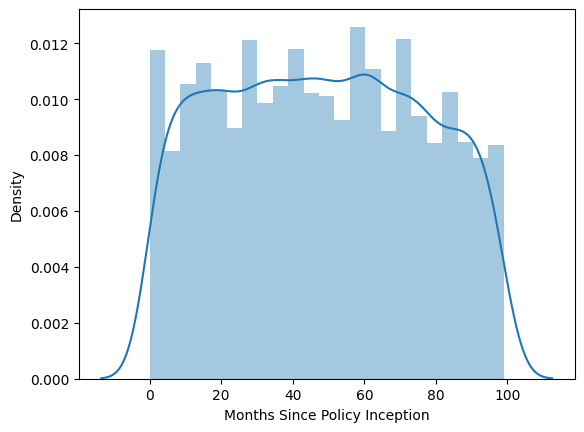

In [ ]:
sns.distplot(df['Months Since Policy Inception'])
plt.show()

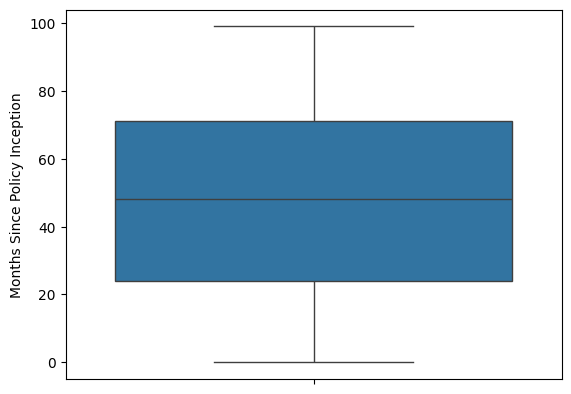

In [ ]:
sns.boxplot(df["Months Since Policy Inception"])
plt.show()

**Total claim amount**

/tmp/ipython-input-3612461602.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Total Claim Amount'])


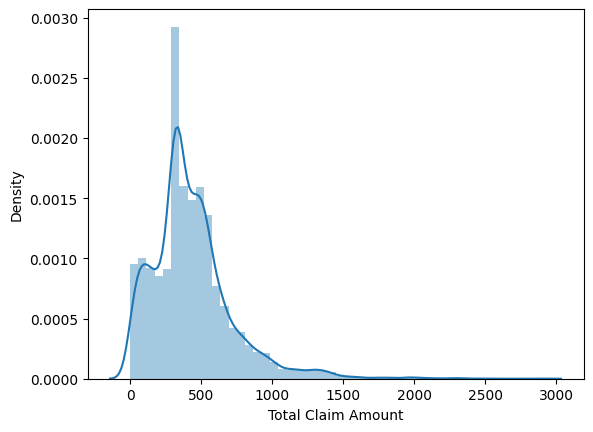

In [ ]:
sns.distplot(df['Total Claim Amount'])
plt.show()

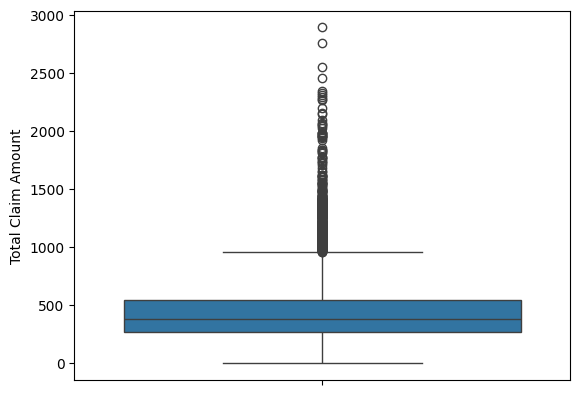

In [ ]:
sns.boxplot(df["Total Claim Amount"])
plt.show()

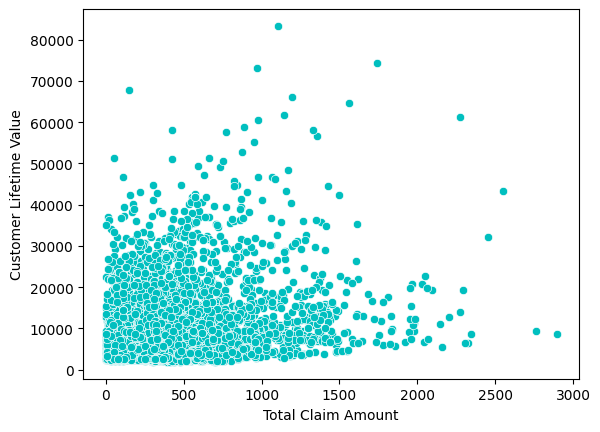

In [ ]:
sns.scatterplot(x=df["Total Claim Amount"],y=df["Customer Lifetime Value"],color='c')
plt.show()

There is a linear relationship between CLV and Total Claim Amount

The monthly premium auto and income feature has multiple peak's so to remove those peaks we can apply any of the power transformation (SQUARE / CUBE)

/tmp/ipython-input-742992871.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.square(df["Monthly Premium Auto"]),color='r')


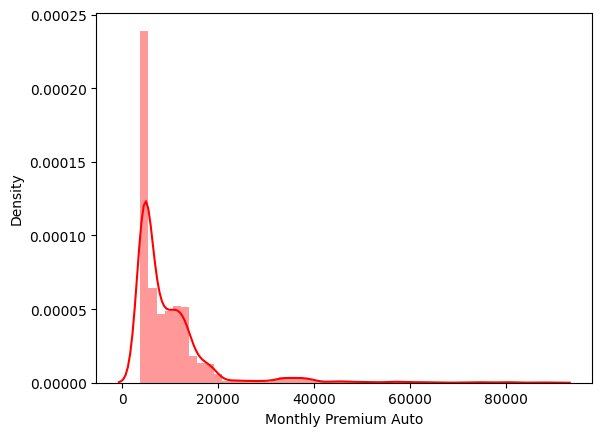

In [ ]:
sns.distplot(np.square(df["Monthly Premium Auto"]),color='r')
plt.show()

/tmp/ipython-input-1182552602.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.square(df["Income"]),color='r')


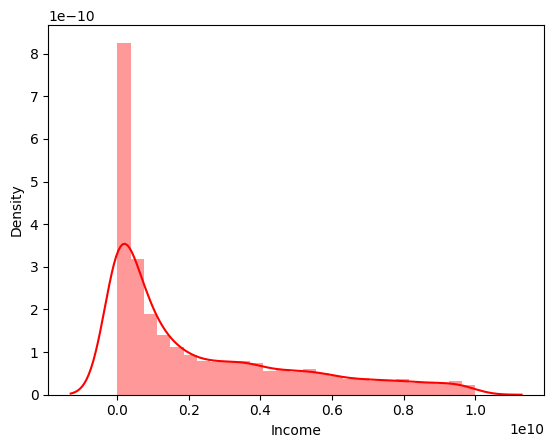

In [ ]:
sns.distplot(np.square(df["Income"]),color='r')
plt.show()

But as we can see that after the square transformation the data is getting heavily skewed, so we stick with the actual distribution again. We will just stick with the actual distribution of the feature in our model building.

**Categorical variables**

In [ ]:
cat_cols = df.select_dtypes(include="object")

In [ ]:
no_col = df[["Number of Open Complaints","Number of Policies"]]

In [ ]:
cat_cols = pd.concat([cat_cols,no_col],axis=1)

In [ ]:
cat_cols.head()

,Customer,State,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Location Code,Marital Status,Policy Type,Policy,Renew Offer Type,Sales Channel,Vehicle Class,Vehicle Size,Number of Open Complaints,Number of Policies
0,BU79786,Washington,No,Basic,Bachelor,2/24/11,Employed,F,Suburban,Married,Corporate Auto,Corporate L3,Offer1,Agent,Two-Door Car,Medsize,0,1
1,QZ44356,Arizona,No,Extended,Bachelor,1/31/11,Unemployed,F,Suburban,Single,Personal Auto,Personal L3,Offer3,Agent,Four-Door Car,Medsize,0,8
2,AI49188,Nevada,No,Premium,Bachelor,2/19/11,Employed,F,Suburban,Married,Personal Auto,Personal L3,Offer1,Agent,Two-Door Car,Medsize,0,2
3,WW63253,California,No,Basic,Bachelor,1/20/11,Unemployed,M,Suburban,Married,Corporate Auto,Corporate L2,Offer1,Call Center,SUV,Medsize,0,7
4,HB64268,Washington,No,Basic,Bachelor,3/2/2011,Employed,M,Rural,Single,Personal Auto,Personal L1,Offer1,Agent,Four-Door Car,Medsize,0,1


In [ ]:
cat_cols.drop("Effective To Date",axis=1,inplace=True)

In [ ]:
cat_cols.columns

Index(['Customer', 'State', 'Response', 'Coverage', 'Education',
       'EmploymentStatus', 'Gender', 'Location Code', 'Marital Status',
       'Policy Type', 'Policy', 'Renew Offer Type', 'Sales Channel',
       'Vehicle Class', 'Vehicle Size', 'Number of Open Complaints',
       'Number of Policies'],
      dtype='object')

In [ ]:
for i in cat_cols:
    print("Unique values in",str(i),"is",df[i].nunique())
    print(df[i].value_counts())
    print("-----------------------------------------")

Unique values in Customer is 9134
Customer
Y167826    1
BU79786    1
QZ44356    1
AI49188    1
WW63253    1
          ..
WC83389    1
OE15005    1
FV94802    1
BW63560    1
IL66569    1
Name: count, Length: 9134, dtype: int64
-----------------------------------------
Unique values in State is 5
State
California    3150
Oregon        2601
Arizona       1703
Nevada         882
Washington     798
Name: count, dtype: int64
-----------------------------------------
Unique values in Response is 2
Response
No     7826
Yes    1308
Name: count, dtype: int64
-----------------------------------------
Unique values in Coverage is 3
Coverage
Basic       5568
Extended    2742
Premium      824
Name: count, dtype: int64
-----------------------------------------
Unique values in Education is 5
Education
Bachelor                2748
College                 2681
High School or Below    2622
Master                   741
Doctor                   342
Name: count, dtype: int64
-------------------------------

Customer column which is the id has unique values for all records so it can be removed for model building as it adds no significance

**State**

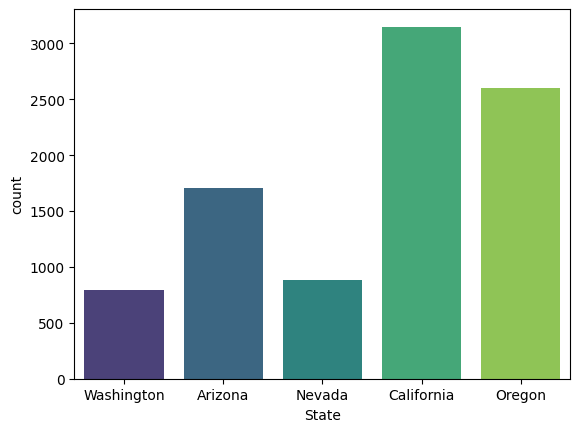

In [ ]:
sns.countplot(data=df, x="State", hue="State", legend=False, palette="viridis")
plt.show()

Most number of people are residing in california

**Response**

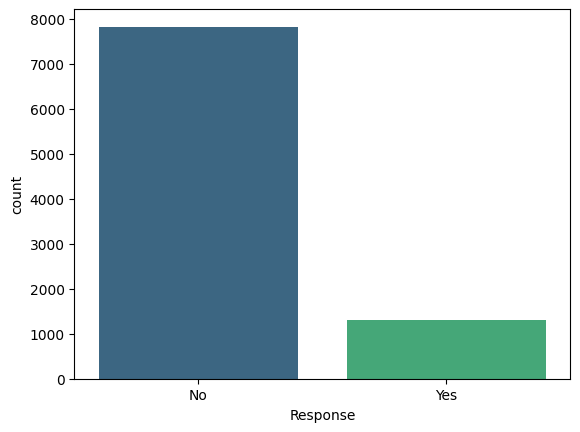

In [ ]:
sns.countplot(data=df, x="Response", hue="Response", legend=False, palette="viridis")
plt.show()

Its seems that less than 1400 customers have responded to the marketing calls

**Coverage**

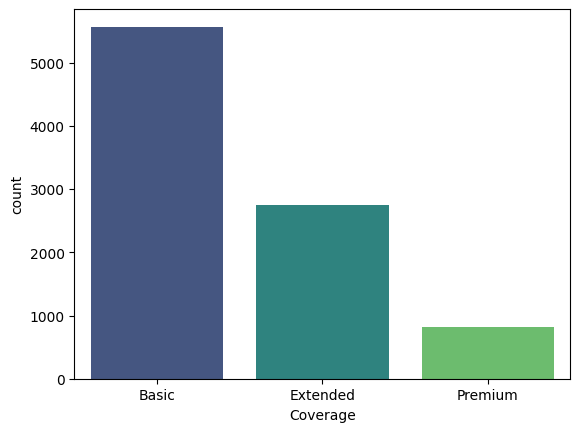

In [ ]:
sns.countplot(data=df, x="Coverage", hue="Coverage", legend=False, palette="viridis")
plt.show()

**Education**

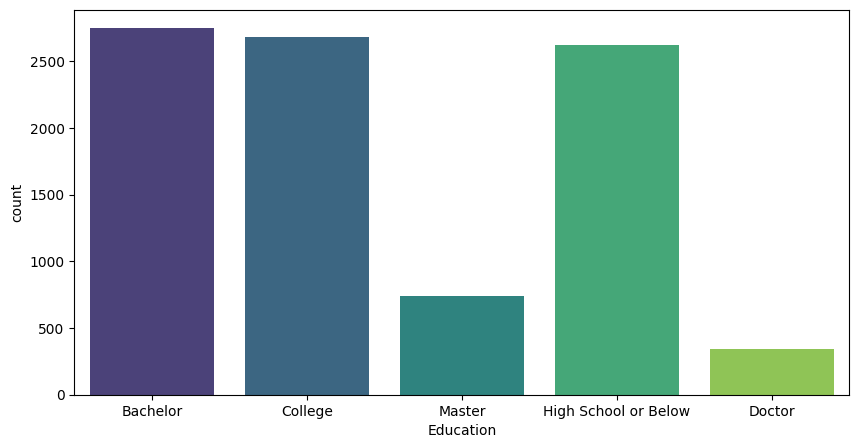

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10,5))

# Plot with Education on x-axis
sns.countplot(x="Education", hue="Education", data=df, palette="viridis", legend=False)
plt.show()


Most of the customers have either a bachelor or college degree

**EmploymentStatus**

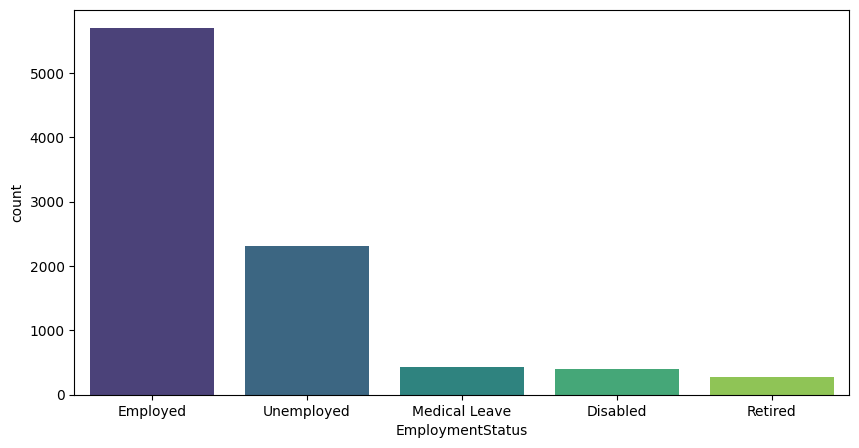

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x="EmploymentStatus", hue="EmploymentStatus", data=df, palette="viridis", legend=False)
# plt.savefig("empstatus.png")
plt.show()

In [ ]:
df["EmploymentStatus"].value_counts(normalize=True)*100

,proportion
EmploymentStatus,
Employed,62.382308
Unemployed,25.366762
Medical Leave,4.729582
Disabled,4.433983
Retired,3.087366


Around 62.38% of the customers are employed

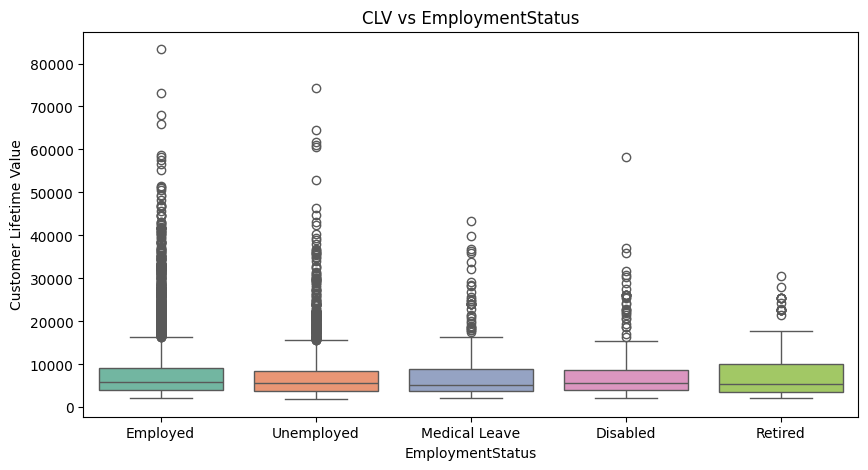

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='EmploymentStatus', y='Customer Lifetime Value', hue='EmploymentStatus', legend=False, palette='Set2')
plt.title("CLV vs EmploymentStatus")
# plt.savefig("bi1.png")
plt.show()

**Gender**

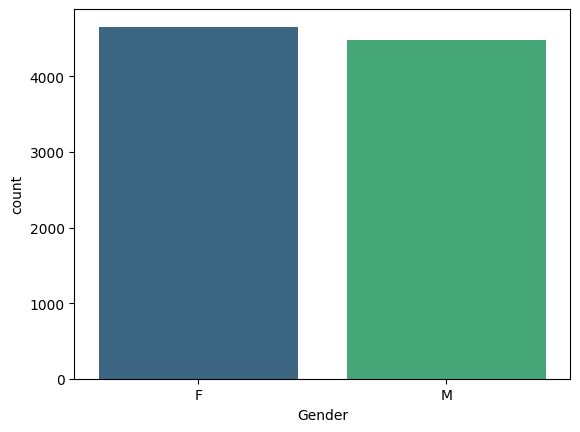

In [ ]:
sns.countplot(x="Gender", hue="Gender", data=df, palette="viridis", legend=False)
plt.show()

**Location Code**

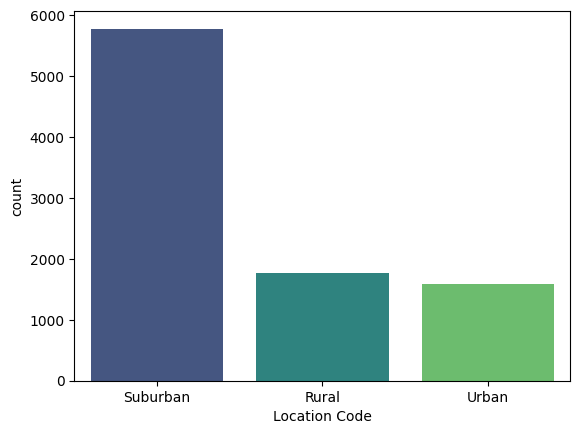

In [ ]:
sns.countplot(x="Location Code", hue="Location Code", data=df, palette="viridis", legend=False)
plt.savefig("location.png")
plt.show()

**Marital Status**

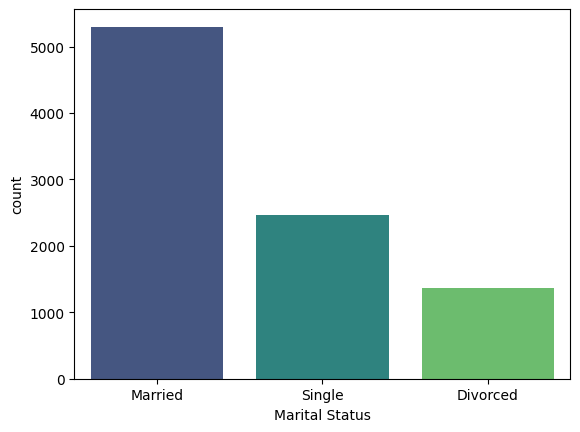

In [ ]:
import pandas as pd
df=pd.read_csv("/content/AutoInsurance.csv.zip")
df.rename(columns={'Customer Lifetime Value':'CLV'},inplace=True)
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Marital Status", hue="Marital Status", data=df, palette="viridis", legend=False)
plt.show()

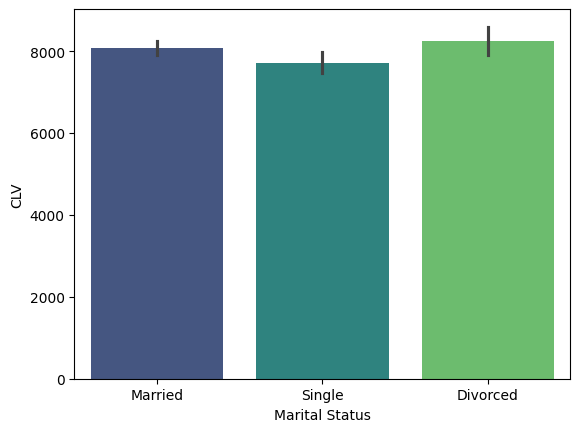

In [ ]:
sns.barplot(x="Marital Status", y="CLV", hue="Marital Status", data=df, palette="viridis", legend=False)
plt.show()

**Policy Type**

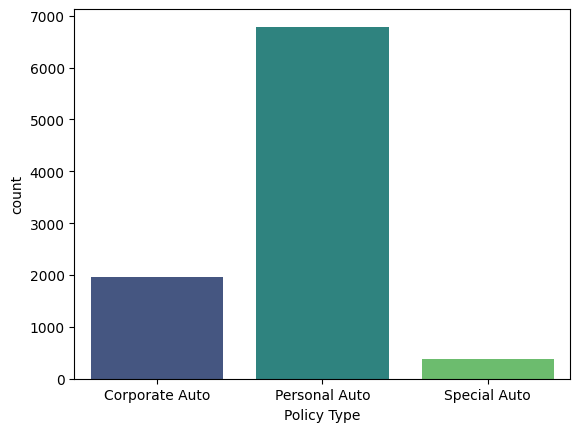

In [ ]:
sns.countplot(x="Policy Type", hue="Policy Type", data=df, palette="viridis", legend=False)
plt.show()

**Policy**

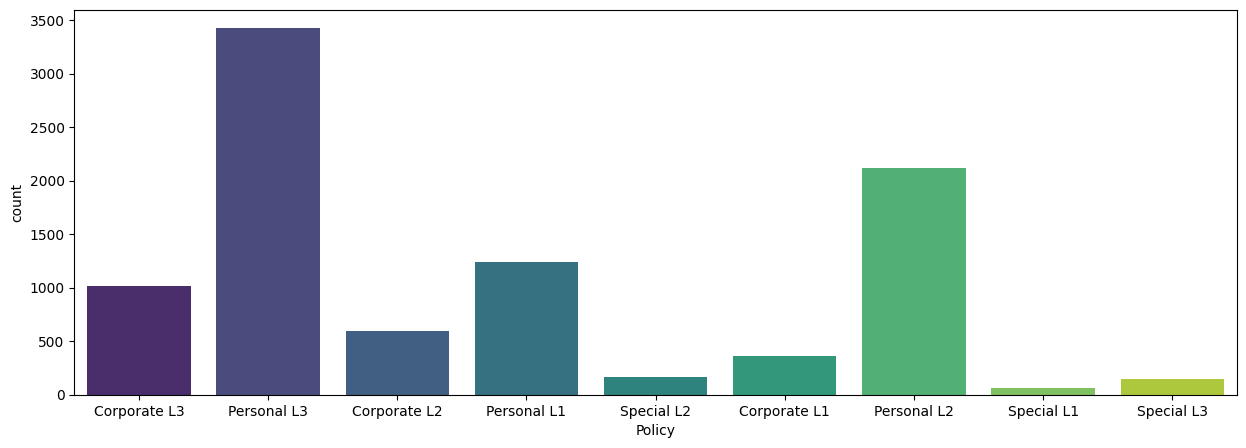

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x="Policy", hue="Policy", data=df, palette="viridis", legend=False)
plt.show()

**Personal L3** policy subcategory has the most number of customers

**Renew Offer type**

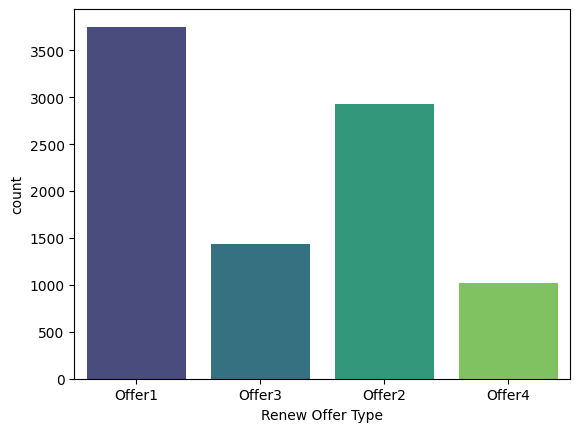

In [ ]:
sns.countplot(x="Renew Offer Type", hue="Renew Offer Type", data=df, palette="viridis", legend=False)
plt.show()

**Sales Channel**

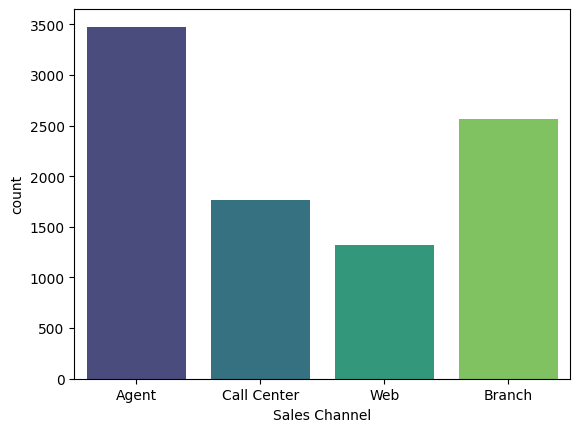

In [ ]:
sns.countplot(x="Sales Channel", hue="Sales Channel", data=df, palette="viridis", legend=False)
plt.show()

**Vehicle Class**

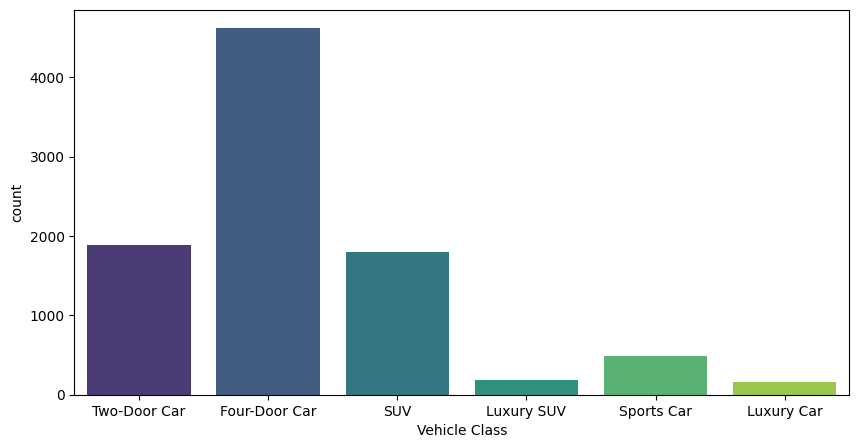

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x="Vehicle Class", hue="Vehicle Class", data=df, palette="viridis", legend=False)
plt.show()

**Vehicle Size**

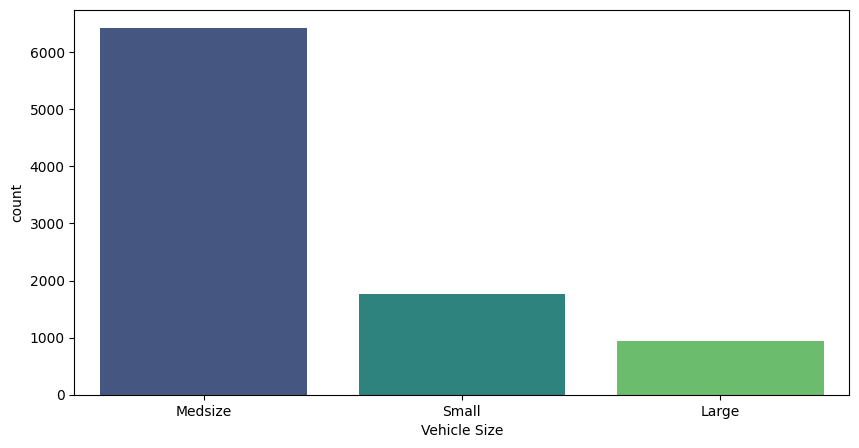

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x="Vehicle Size", hue="Vehicle Size", data=df, palette="viridis", legend=False)
plt.show()

**Number of Open Complaints**

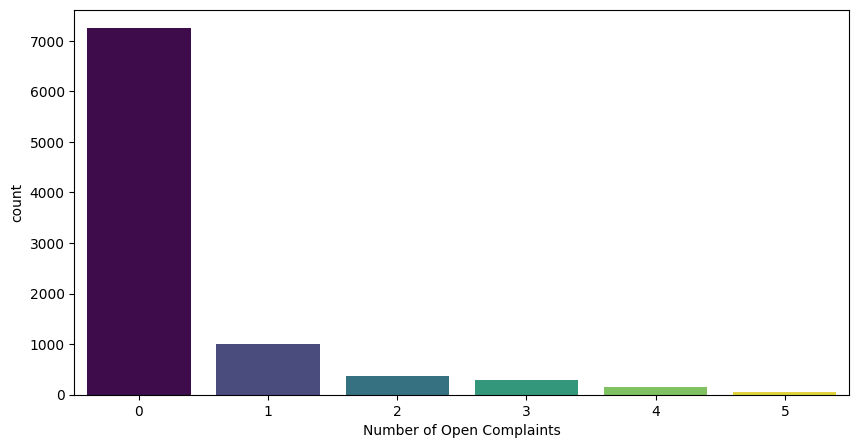

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x="Number of Open Complaints", hue="Number of Open Complaints", data=df, palette="viridis", legend=False)
plt.show()

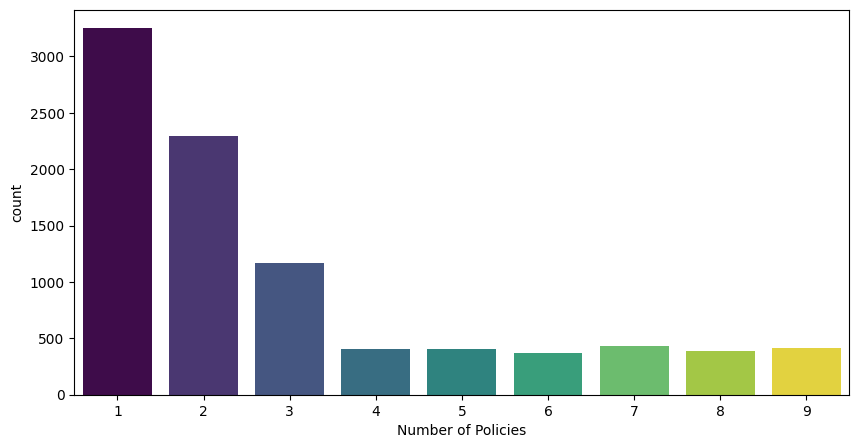

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x="Number of Policies", hue="Number of Policies", data=df, palette="viridis", legend=False)
plt.show()

In [ ]:
df['Effective To Date']=pd.to_datetime(df['Effective To Date'],infer_datetime_format=True)

/tmp/ipython-input-3319306827.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df['Effective To Date']=pd.to_datetime(df['Effective To Date'],infer_datetime_format=True)
/tmp/ipython-input-3319306827.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Effective To Date']=pd.to_datetime(df['Effective To Date'],infer_datetime_format=True)


In [ ]:
df["Months"] = df["Effective To Date"].dt.month

In [ ]:
df['Months'] = df['Months'].astype('object')

**Months**

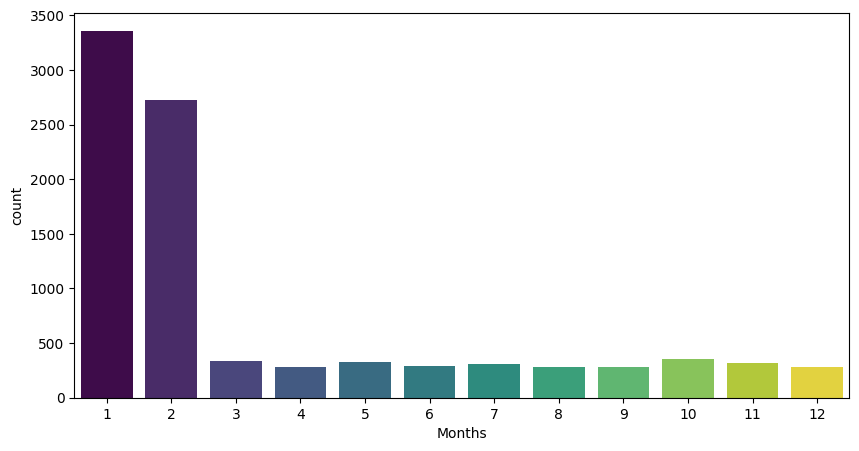

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x="Months", hue="Months", data=df, palette="viridis", legend=False)
plt.show()

In [ ]:
cat_cols = df.select_dtypes(include="object")

In [ ]:
no_col = df[["Number of Open Complaints","Number of Policies"]]

In [ ]:
cat_cols = pd.concat([cat_cols,no_col],axis=1)

In [ ]:
# cat_cols.drop("Effective To Date",axis=1,inplace=True)

In [ ]:
display(cat_cols.head())

,Customer,State,Response,Coverage,Education,EmploymentStatus,Gender,Location Code,Marital Status,Policy Type,Policy,Renew Offer Type,Sales Channel,Vehicle Class,Vehicle Size,Months,Number of Open Complaints,Number of Policies
0,BU79786,Washington,No,Basic,Bachelor,Employed,F,Suburban,Married,Corporate Auto,Corporate L3,Offer1,Agent,Two-Door Car,Medsize,2,0,1
1,QZ44356,Arizona,No,Extended,Bachelor,Unemployed,F,Suburban,Single,Personal Auto,Personal L3,Offer3,Agent,Four-Door Car,Medsize,1,0,8
2,AI49188,Nevada,No,Premium,Bachelor,Employed,F,Suburban,Married,Personal Auto,Personal L3,Offer1,Agent,Two-Door Car,Medsize,2,0,2
3,WW63253,California,No,Basic,Bachelor,Unemployed,M,Suburban,Married,Corporate Auto,Corporate L2,Offer1,Call Center,SUV,Medsize,1,0,7
4,HB64268,Washington,No,Basic,Bachelor,Employed,M,Rural,Single,Personal Auto,Personal L1,Offer1,Agent,Four-Door Car,Medsize,3,0,1


In [ ]:
cat_cols.columns

Index(['Customer', 'State', 'Response', 'Coverage', 'Education',
       'EmploymentStatus', 'Gender', 'Location Code', 'Marital Status',
       'Policy Type', 'Policy', 'Renew Offer Type', 'Sales Channel',
       'Vehicle Class', 'Vehicle Size', 'Months', 'Number of Open Complaints',
       'Number of Policies'],
      dtype='object')

In [ ]:
df.columns

Index(['Customer', 'State', 'CLV', 'Response', 'Coverage', 'Education',
       'Effective To Date', 'EmploymentStatus', 'Gender', 'Income',
       'Location Code', 'Marital Status', 'Monthly Premium Auto',
       'Months Since Last Claim', 'Months Since Policy Inception',
       'Number of Open Complaints', 'Number of Policies', 'Policy Type',
       'Policy', 'Renew Offer Type', 'Sales Channel', 'Total Claim Amount',
       'Vehicle Class', 'Vehicle Size', 'Months'],
      dtype='object')

**HeatMap**

In [ ]:
heatmap = df[['CLV', 'Income', 'Monthly Premium Auto','Total Claim Amount']]

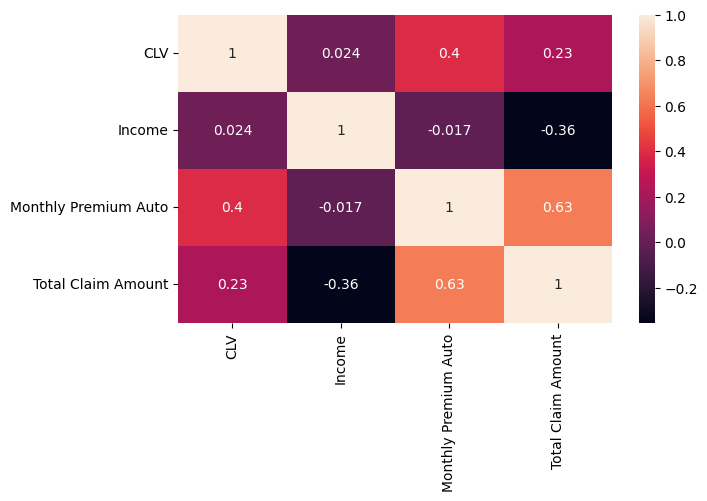

In [ ]:
plt.figure(figsize=(7,4))
sns.heatmap(heatmap.corr(),annot=True)
# plt.savefig("Heatmap.png")
plt.show()

We can clearly see in the heatmap, that customer lifetime value has a better correlation with monthly premium auto and acceptable correlation with total claim amount.

**Statistical Significance**

1.   H0:The null hypothesis of the test is the data is normally distributed
2.   HA:The data is not normally distributed

In [ ]:
import scipy.stats as stats
stats.shapiro(df['CLV'])

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9134.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=np.float64(0.7033723183514178), pvalue=np.float64(4.0169007188037684e-83))

(0.7033728361129761, 0.0)

p-value less than 0.05 we reject null hypothesis the data is not normally distributed

We will proceed with non parametric tests since the dependent variable is not normally distributed

In [ ]:
columns_cat = list(cat_cols.columns)
columns_cat

['Customer',
 'State',
 'Response',
 'Coverage',
 'Education',
 'EmploymentStatus',
 'Gender',
 'Location Code',
 'Marital Status',
 'Policy Type',
 'Policy',
 'Renew Offer Type',
 'Sales Channel',
 'Vehicle Class',
 'Vehicle Size',
 'Months',
 'Number of Open Complaints',
 'Number of Policies']

In [ ]:
manwhiteneyy = []
anova = []

for i in columns_cat:
    if (df[i].nunique()>2):
        anova.append(i)
    else:
        manwhiteneyy.append(i)
print("Anova:",anova)
print("TTest:",manwhiteneyy)

Anova: ['Customer', 'State', 'Coverage', 'Education', 'EmploymentStatus', 'Location Code', 'Marital Status', 'Policy Type', 'Policy', 'Renew Offer Type', 'Sales Channel', 'Vehicle Class', 'Vehicle Size', 'Months', 'Number of Open Complaints', 'Number of Policies']
TTest: ['Response', 'Gender']


H0, the distributions of both populations are equal The alternative hypothesis H1 is that the distributions are not equal.

/tmp/ipython-input-1579086524.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(yes)
/tmp/ipython-input-1579086524.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(no)


<Axes: xlabel='CLV', ylabel='Density'>

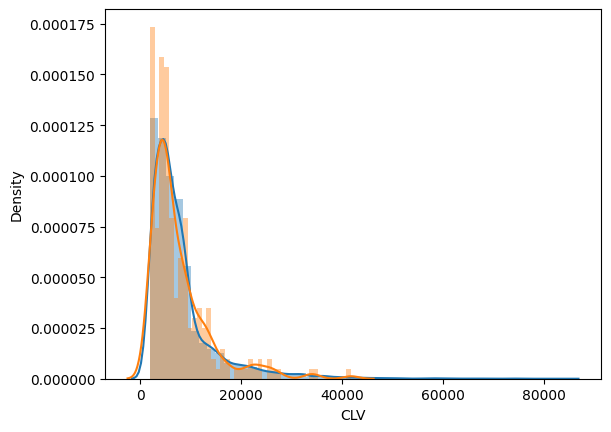

In [ ]:
yes=df[df['Response']=='No']['CLV']
no=df[df['Response']=='Yes']['CLV']

sns.distplot(yes)
sns.distplot(no)

If the distributions are identical, which is the null hypothesis of the Mann-Whitney U test, the mean rank will be the same

In [ ]:
f = stats.mannwhitneyu(yes,no)
print(f)

MannwhitneyuResult(statistic=np.float64(5175420.0), pvalue=np.float64(0.5168872245291198))


p-value is greater than 0.05 we failed to reject null hypothesis i.e the mean rank will be the same for both males and females.

In [ ]:
male=df[df['Gender']=='M']['CLV']
female=df[df['Gender']=='F']['CLV']

b =stats.mannwhitneyu(male,female)
print(b)

MannwhitneyuResult(statistic=np.float64(10337134.0), pvalue=np.float64(0.48749303056449833))


p-value is greater than 0.05 we failed to reject null hypothesis i.e the mean rank will be the same for both males and females.

we test above two features with non-Paramteric unpaired ttest and we concluded that those 2 features is not significant to predict traget


*   H1:the mean ranks of the groups are not the same.
*   H0:the mean ranks of the groups are the same.




In [ ]:
ca=df[df['State']=='California']['CLV']
Or=df[df['State']=='Oregon']['CLV']
Ar=df[df['State']=='Arizona']['CLV']
Ne=df[df['State']=='Nevada']['CLV']
Wa=df[df['State']=='Washington']['CLV']


a = stats.kruskal(ca,Or,Ar,Ne,Wa)
print(a)

KruskalResult(statistic=np.float64(5.072069583836472), pvalue=np.float64(0.27998232358818953))


p-value > 0.05 failed to reject H0

In [ ]:
stats.f_oneway(ca,Or,Ar,Ne,Wa)
print(b)

MannwhitneyuResult(statistic=np.float64(10337134.0), pvalue=np.float64(0.48749303056449833))


/tmp/ipython-input-3416744090.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Ba,hist=False,label='Basic')
/tmp/ipython-input-3416744090.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(Ex,hist=False)
/tmp/ipython-input-3416744090.py:9: UserWarning: 

`distplot` is a dep

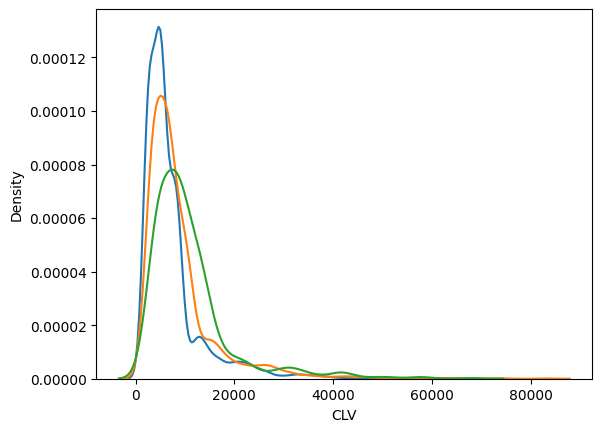

In [ ]:
# df.rename(columns={'CLV':'CLV'},inplace=True)

Ba=df[df['Coverage']=='Basic']['CLV']
Ex=df[df['Coverage']=='Extended']['CLV']
Pr=df[df['Coverage']=='Premium']['CLV']

sns.distplot(Ba,hist=False,label='Basic')
sns.distplot(Ex,hist=False)
sns.distplot(Pr,hist=False)
plt.show()

In [ ]:
c =stats.kruskal(Ba,Ex,Pr)
print(c)

KruskalResult(statistic=np.float64(502.4996090762843), pvalue=np.float64(7.648852917746348e-110))


p-value < 0.05 to reject H0

In [ ]:
stats.f_oneway(Ba,Ex,Pr)

F_onewayResult(statistic=np.float64(133.67511419504908), pvalue=np.float64(6.0158970099807e-58))

In [ ]:
Ba=df[df['Education']=='Bachelor']['CLV']
Co=df[df['Education']=='College']['CLV']
Hi=df[df['Education']=='High School or Below']['CLV']
Ma=df[df['Education']=='Master']['CLV']
Da=df[df['Education']=='Doctor']['CLV']

d= stats.kruskal(Ba,Co,Hi,Ma,Da)
print(d)

KruskalResult(statistic=np.float64(12.234061758188824), pvalue=np.float64(0.015693004298603028))


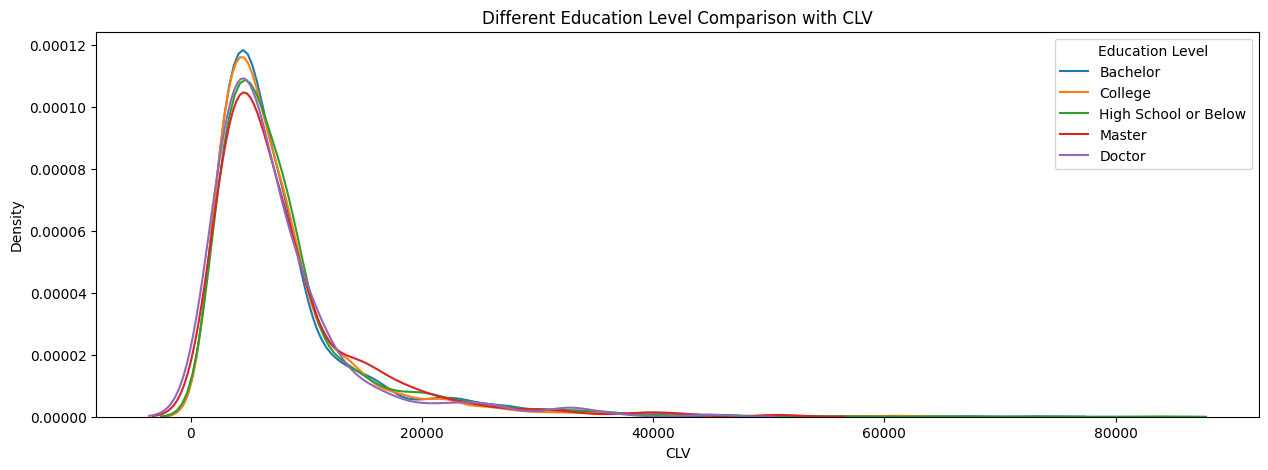

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,5))

sns.kdeplot(Ba, label='Bachelor')
sns.kdeplot(Co, label='College')
sns.kdeplot(Hi, label='High School or Below')
sns.kdeplot(Ma, label='Master')
sns.kdeplot(Da, label='Doctor')

plt.title("Different Education Level Comparison with CLV")
plt.xlabel("CLV")
plt.ylabel("Density")
plt.legend(title="Education Level")   # Legend title added
# plt.savefig("Education.png")
plt.show()

In [ ]:
Ba=df[df['EmploymentStatus']=='Employed']['CLV']
Co=df[df['EmploymentStatus']=='Unemployed']['CLV']
Hi=df[df['EmploymentStatus']=='Medical Leave']['CLV']
Ma=df[df['EmploymentStatus']=='Disabled']['CLV']
Da=df[df['EmploymentStatus']=='Retired']['CLV']

e = stats.kruskal(Ba,Co,Hi,Ma,Da)
print(e)

KruskalResult(statistic=np.float64(42.56159302970864), pvalue=np.float64(1.2758458797542519e-08))


p-value < 0.05 reject H0, EmploymentStatus is significant in predicting CLV

In [ ]:
Ba=df[df['Location Code']=='Suburban']['CLV']
Co=df[df['Location Code']=='Rural']['CLV']
Hi=df[df['Location Code']=='Urban']['CLV']

g = stats.kruskal(Ba,Co,Hi)
print(g)

KruskalResult(statistic=np.float64(2.4638212999332567), pvalue=np.float64(0.29173464205664124))


p-value < 0.05 reject H0, Location Code can be significant in predicting CLV

In [ ]:
Ba=df[df['Marital Status']=='Married']['CLV']
Co=df[df['Marital Status']=='Single']['CLV']
Hi=df[df['Marital Status']=='Divorced']['CLV']

h = stats.kruskal(Ba,Co,Hi)
print(h)

KruskalResult(statistic=np.float64(20.895798766808223), pvalue=np.float64(2.9009146434700455e-05))


p-value < 0.05 reject H0, Marital Status can be significant in predicting CLV

In [ ]:
Ba=df[df['Number of Open Complaints']==0]['CLV']
Co=df[df['Number of Open Complaints']==1]['CLV']
Hi=df[df['Number of Open Complaints']==2]['CLV']
Ma=df[df['Number of Open Complaints']==3]['CLV']
Da=df[df['Number of Open Complaints']==4]['CLV']
As=df[df['Number of Open Complaints']==5]['CLV']

o = stats.kruskal(Ba,Co,Hi,Ma,Da,As)
print(o)

KruskalResult(statistic=np.float64(29.160617988301833), pvalue=np.float64(2.1564409504417123e-05))


p-value < 0.05 reject H0, Number of Open Complaints can be significant in predicting CLV

In [ ]:
Ba=df[df['Number of Policies']==1]['CLV']
Co=df[df['Number of Policies']==2]['CLV']
Hi=df[df['Number of Policies']==3]['CLV']

p = stats.kruskal(Ba,Co,Hi)
print(p)

KruskalResult(statistic=np.float64(5017.7060662040785), pvalue=np.float64(0.0))


p-value < 0.05 reject H0, Number of Policies can be significant in predicting CLV

In [ ]:
Ba=df[df['Policy Type']=='Personal Auto']['CLV']
Co=df[df['Policy Type']=='Corporate Auto']['CLV']
Hi=df[df['Policy Type']=='Special Auto']['CLV']

i = stats.kruskal(Ba,Co,Hi)
print(i)

KruskalResult(statistic=np.float64(4.6074986354931795), pvalue=np.float64(0.0998836452694168))


p-value > 0.05 failed to reject H0, Policy Type may not be significant in predicting CLV

In [ ]:
Ba=df[df['Policy']=='Personal L3']['CLV']
Co=df[df['Policy']=='Personal L2']['CLV']
Hi=df[df['Policy']=='Personal L1']['CLV']
Ma=df[df['Policy']=='Corporate L3']['CLV']
Da=df[df['Policy']=='Corporate L2']['CLV']
Ca=df[df['Policy']=='Corporate L1']['CLV']
s1=df[df['Policy']=='Special L2']['CLV']
s2=df[df['Policy']=='Special L3']['CLV']
s3=df[df['Policy']=='Special L1']['CLV']

j =stats.kruskal(Ba,Co,Hi,Ma,Da,Ca,s1,s2,s3)
print(j)

KruskalResult(statistic=np.float64(7.944351884462466), pvalue=np.float64(0.4389248352544014))


p-value > 0.05 failed to reject H0, Policy may not be significant in predicting CLV

In [ ]:
Ba=df[df['Renew Offer Type']=='Offer1']['CLV']
Co=df[df['Renew Offer Type']=='Offer2']['CLV']
Hi=df[df['Renew Offer Type']=='Offer3']['CLV']
Ma=df[df['Renew Offer Type']=='Offer4']['CLV']

k =stats.kruskal(Ba,Co,Hi,Ma)
print(k)

KruskalResult(statistic=np.float64(168.90219457792458), pvalue=np.float64(2.196144881912684e-36))


p-value < 0.05 reject H0, Number of Policies can be significant in predicting CLV

In [ ]:
Ba=df[df['Sales Channel']=='Agent']['CLV']
Co=df[df['Sales Channel']=='Branch']['CLV']
Hi=df[df['Sales Channel']=='Call Center']['CLV']
Ma=df[df['Sales Channel']=='Web']['CLV']

l = stats.kruskal(Ba,Co,Hi,Ma)
print(l)

KruskalResult(statistic=np.float64(4.491751501229693), pvalue=np.float64(0.2130272157209903))


p-value > 0.05 failed to reject H0, Sales Channel may not be significant in predicting CLV

In [ ]:
Ba=df[df['Vehicle Class']=='Four-Door Car']['CLV']
Co=df[df['Vehicle Class']=='Two-Door Car']['CLV']
Hi=df[df['Vehicle Class']=='SUV']['CLV']
Ma=df[df['Vehicle Class']=='Sports Car']['CLV']
Da=df[df['Vehicle Class']=='Luxury SUV']['CLV']
Ca=df[df['Vehicle Class']=='Luxury Car']['CLV']


m = stats.kruskal(Ba,Co,Hi,Ma,Da,Ca)
print(m)

KruskalResult(statistic=np.float64(1310.5494960284416), pvalue=np.float64(3.309676344717952e-281))


p-value < 0.05 reject H0, Vehicle Class can be significant in predicting CLV

In [ ]:
Ba=df[df['Vehicle Size']=='Medsize']['CLV']
Co=df[df['Vehicle Size']=='Small']['CLV']
Hi=df[df['Vehicle Size']=='Large']['CLV']

n =stats.kruskal(Ba,Co,Hi)
print(n)

KruskalResult(statistic=np.float64(9.564995661218877), pvalue=np.float64(0.00837505335446059))


p-value < 0.05 reject H0, Vehicle Class can be significant in predicting CLV

In [ ]:
columns_cat

['Customer',
 'State',
 'Response',
 'Coverage',
 'Education',
 'EmploymentStatus',
 'Gender',
 'Location Code',
 'Marital Status',
 'Policy Type',
 'Policy',
 'Renew Offer Type',
 'Sales Channel',
 'Vehicle Class',
 'Vehicle Size',
 'Months',
 'Number of Open Complaints',
 'Number of Policies']

In [ ]:
cat_cols.drop("Customer",axis=1,inplace=True)
cat_cols

,State,Response,Coverage,Education,EmploymentStatus,Gender,Location Code,Marital Status,Policy Type,Policy,Renew Offer Type,Sales Channel,Vehicle Class,Vehicle Size,Months,Number of Open Complaints,Number of Policies
0,Washington,No,Basic,Bachelor,Employed,F,Suburban,Married,Corporate Auto,Corporate L3,Offer1,Agent,Two-Door Car,Medsize,2,0,1
1,Arizona,No,Extended,Bachelor,Unemployed,F,Suburban,Single,Personal Auto,Personal L3,Offer3,Agent,Four-Door Car,Medsize,1,0,8
2,Nevada,No,Premium,Bachelor,Employed,F,Suburban,Married,Personal Auto,Personal L3,Offer1,Agent,Two-Door Car,Medsize,2,0,2
3,California,No,Basic,Bachelor,Unemployed,M,Suburban,Married,Corporate Auto,Corporate L2,Offer1,Call Center,SUV,Medsize,1,0,7
4,Washington,No,Basic,Bachelor,Employed,M,Rural,Single,Personal Auto,Personal L1,Offer1,Agent,Four-Door Car,Medsize,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9129,California,No,Basic,Bachelor,Employed,M,Urban,Married,Personal Auto,Personal L1,Offer2,Web,Four-Door Car,Medsize,10,0,2
9130,California,Yes,Extended,College,Employed,F,Suburban,Divorced,Corporate Auto,Corporate L3,Offer1,Branch,Four-Door Car,Medsize,12,0,1
9131,California,No,Extended,Bachelor,Unemployed,M,Suburban,Single,Corporate Auto,Corporate L2,Offer1,Branch,Four-Door Car,Medsize,6,3,2
9132,California,No,Extended,College,Employed,M,Suburban,Married,Personal Auto,Personal L2,Offer3,Branch,Four-Door Car,Large,3,0,3


In [ ]:
p_values = [a[1],b[1],c[1],d[1],e[1],f[1],g[1],h[1],i[1],j[1],k[1],l[1],m[1],n[1],o[1],p[1]]
p_values

[np.float64(0.27998232358818953),
 np.float64(0.48749303056449833),
 np.float64(7.648852917746348e-110),
 np.float64(0.015693004298603028),
 np.float64(1.2758458797542519e-08),
 np.float64(0.5168872245291198),
 np.float64(0.29173464205664124),
 np.float64(2.9009146434700455e-05),
 np.float64(0.0998836452694168),
 np.float64(0.4389248352544014),
 np.float64(2.196144881912684e-36),
 np.float64(0.2130272157209903),
 np.float64(3.309676344717952e-281),
 np.float64(0.00837505335446059),
 np.float64(2.1564409504417123e-05),
 np.float64(0.0)]

In [ ]:
len(p_values)

16

In [ ]:
len(cat_cols.columns)

17

In [ ]:
pd.DataFrame(p_values, index=(cat_cols.columns.drop('Months')), columns=['P_Value'])

,P_Value
State,2.799823e-01
Response,4.874930e-01
Coverage,7.648853e-110
Education,1.569300e-02
EmploymentStatus,1.275846e-08
Gender,5.168872e-01
Location Code,2.917346e-01
Marital Status,2.900915e-05
Policy Type,9.988365e-02
Policy,4.389248e-01


Coverage,Education,EmploymentStatus,Marital Status, Renew Offer Type, Vehicle class, Vehicle class, Number of open complaints and No of Policies play a significant role in predicting the CLV

In [ ]:
numerical_cols = df.select_dtypes(include=["int64","float64"])

In [ ]:
numerical_cols = numerical_cols.drop(["Number of Policies","Number of Open Complaints"],axis=1, errors='ignore')

In [ ]:
display(numerical_cols.head())

,CLV,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Total Claim Amount
0,2763.519279,56274,69,32,5,384.811147
1,6979.535903,0,94,13,42,1131.464935
2,12887.431650,48767,108,18,38,566.472247
3,7645.861827,0,106,18,65,529.881344
4,2813.692575,43836,73,12,44,138.130879


In [ ]:
cat_cols.head()

,State,Response,Coverage,Education,EmploymentStatus,Gender,Location Code,Marital Status,Policy Type,Policy,Renew Offer Type,Sales Channel,Vehicle Class,Vehicle Size,Months,Number of Open Complaints,Number of Policies
0,Washington,No,Basic,Bachelor,Employed,F,Suburban,Married,Corporate Auto,Corporate L3,Offer1,Agent,Two-Door Car,Medsize,2,0,1
1,Arizona,No,Extended,Bachelor,Unemployed,F,Suburban,Single,Personal Auto,Personal L3,Offer3,Agent,Four-Door Car,Medsize,1,0,8
2,Nevada,No,Premium,Bachelor,Employed,F,Suburban,Married,Personal Auto,Personal L3,Offer1,Agent,Two-Door Car,Medsize,2,0,2
3,California,No,Basic,Bachelor,Unemployed,M,Suburban,Married,Corporate Auto,Corporate L2,Offer1,Call Center,SUV,Medsize,1,0,7
4,Washington,No,Basic,Bachelor,Employed,M,Rural,Single,Personal Auto,Personal L1,Offer1,Agent,Four-Door Car,Medsize,3,0,1


In [ ]:
import statsmodels.api as sm
# X=numerical_cols.drop(['CLV'],axis=1)
# y=numerical_cols['CLV']
# lin_reg=sm.OLS(y,X).fit()
# lin_reg.summary()

**Data Preprocessing**

In [ ]:
cat_cols.head()

,State,Response,Coverage,Education,EmploymentStatus,Gender,Location Code,Marital Status,Policy Type,Policy,Renew Offer Type,Sales Channel,Vehicle Class,Vehicle Size,Months,Number of Open Complaints,Number of Policies
0,Washington,No,Basic,Bachelor,Employed,F,Suburban,Married,Corporate Auto,Corporate L3,Offer1,Agent,Two-Door Car,Medsize,2,0,1
1,Arizona,No,Extended,Bachelor,Unemployed,F,Suburban,Single,Personal Auto,Personal L3,Offer3,Agent,Four-Door Car,Medsize,1,0,8
2,Nevada,No,Premium,Bachelor,Employed,F,Suburban,Married,Personal Auto,Personal L3,Offer1,Agent,Two-Door Car,Medsize,2,0,2
3,California,No,Basic,Bachelor,Unemployed,M,Suburban,Married,Corporate Auto,Corporate L2,Offer1,Call Center,SUV,Medsize,1,0,7
4,Washington,No,Basic,Bachelor,Employed,M,Rural,Single,Personal Auto,Personal L1,Offer1,Agent,Four-Door Car,Medsize,3,0,1


In [ ]:
catg=pd.get_dummies(cat_cols,drop_first=True)
numerical_cols.head()

,CLV,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Total Claim Amount
0,2763.519279,56274,69,32,5,384.811147
1,6979.535903,0,94,13,42,1131.464935
2,12887.431650,48767,108,18,38,566.472247
3,7645.861827,0,106,18,65,529.881344
4,2813.692575,43836,73,12,44,138.130879


In [ ]:
dfn = pd.concat([numerical_cols,catg],axis=1)
dfn.head()

,CLV,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Total Claim Amount,Number of Open Complaints,Number of Policies,State_California,State_Nevada,...,Months_3,Months_4,Months_5,Months_6,Months_7,Months_8,Months_9,Months_10,Months_11,Months_12
0,2763.519279,56274,69,32,5,384.811147,0,1,False,False,...,False,False,False,False,False,False,False,False,False,False
1,6979.535903,0,94,13,42,1131.464935,0,8,False,False,...,False,False,False,False,False,False,False,False,False,False
2,12887.431650,48767,108,18,38,566.472247,0,2,False,True,...,False,False,False,False,False,False,False,False,False,False
3,7645.861827,0,106,18,65,529.881344,0,7,True,False,...,False,False,False,False,False,False,False,False,False,False
4,2813.692575,43836,73,12,44,138.130879,0,1,False,False,...,True,False,False,False,False,False,False,False,False,False


**OLS Model**

In [ ]:
dfn.rename(columns={'CLV':'CLV'},inplace=True)

X=dfn.drop(['CLV'],axis=1)
# Convert boolean columns to integers (0 and 1)
X = X.astype(int, errors='ignore')
y=dfn['CLV']
X_constant=sm.add_constant(X)
lin_reg=sm.OLS(y,X_constant).fit()
lin_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CLV   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.165
Method:                 Least Squares   F-statistic:                     31.69
Date:                Sat, 21 Feb 2026   Prob (F-statistic):          1.19e-317
Time:                        11:25:49   Log-Likelihood:                -92804.
No. Observations:                9134   AIC:                         1.857e+05
Df Residuals:                    9074   BIC:                         1.862e+05
Df Model:                          59                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                           1694.9172    908.525      1.866      0.062     -85.996    3475.831
Income                            -0.0012      0.004     -0.306      0.760      -0.009       0.006
Monthly Premium Auto              69.8766     10.029      6.967      0.000      50.217      89.536
Months Since Last Claim            6.8324      6.563      1.041      0.298      -6.032      19.696
Months Since Policy Inception     -1.3171      2.381     -0.553      0.580      -5.984       3.350
Total Claim Amount                -0.2017      0.474     -0.425      0.671      -1.132       0.728
Number of Open Complaints       -265.7797     72.550     -3.663      0.000    -407.994    -123.566
Number of Policies                57.8862     27.760      2.085      0.037       3.470     112.302
State_California                  22.8819    189.622      0.121      0.904    -348.819     394.583
State_Nevada                      35.3191    261.311      0.135      0.892    -476.909     547.548
State_Oregon                      84.5894    196.200      0.431      0.666    -300.007     469.186
State_Washington                 158.2524    270.063      0.586      0.558    -371.132     687.637
Response_Yes                    -244.8859    208.137     -1.177      0.239    -652.882     163.110
Coverage_Extended                134.5970    249.427      0.540      0.589    -354.336     623.530
Coverage_Premium                  40.0775    527.771      0.076      0.939    -994.473    1074.628
Education_College                 -9.5393    171.374     -0.056      0.956    -345.471     326.393
Education_Doctor                -225.5786    363.279     -0.621      0.535    -937.687     486.530
Education_High School or Below   389.0053    173.498      2.242      0.025      48.911     729.100
Education_Master                 149.0578    262.958      0.567      0.571    -366.399     664.515
EmploymentStatus_Employed        710.4538    354.530      2.004      0.045      15.494    1405.413
EmploymentStatus_Medical Leave   242.0735    436.897      0.554      0.580    -614.343    1098.490
EmploymentStatus_Retired         114.2390    503.513      0.227      0.821    -872.761    1101.239
EmploymentStatus_Unemployed       14.1314    357.811      0.039      0.968    -687.258     715.521
Gender_M                        -143.5776    132.972     -1.080      0.280    -404.232     117.077
Location Code_Suburban           -90.8257    263.602     -0.345      0.730    -607.546     425.895
Location Code_Urban              118.7775    241.608      0.492      0.623    -354.828     592.383
Marital Status_Married          -186.5727    194.932     -0.957      0.339    -568.684     195.538
Marital Status_Single           -504.5284    226.004     -2.232      0.026    -947.546     -61.511
Policy Type_Pe

Warnings:

[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.

[2] The smallest eigenvalue is 1.29e-19. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.

**Assumptions**


No autocorrelation
Linearity of residuals
Normality of error terms
No Heteroscedacity
No strong MultiCollinearity


**Assumption 1 No Auto correlation**

Test needed : Durbin- Watson Test.

It's value ranges from 0-4. If the value of Durbin- Watson is Between 0-2, it's known as Positive Autocorrelation. If the value ranges from 2-4, it is known as Negative autocorrelation. If the value is exactly 2, it means No Autocorrelation. For a good linear model, it should have low or no autocorrelation. we can see here the values of dublin watson test: 1.995 (No AUTO-CORRELATION)

From the graph below, we can easily see that there is no autocorrelation.

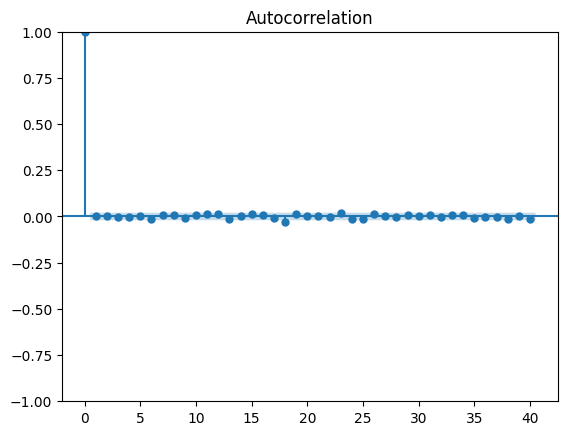

In [ ]:
import statsmodels.tsa.api as smt #timeseries analysis

acf = smt.graphics.plot_acf(lin_reg.resid, lags=40 , alpha=0.05)#auto_correlation value, lags= previous value
acf.show()

Assumption 2- Normality of Residuals 2) The second assumption is the Normality of Residuals / Error terms.


For this we prefer the Jarque Bera test. For a good model, the residuals should be normally distributed. The higher the value of Jarque Bera test , the lesser the residuals are normally distributed. We generally prefer a lower value of jarque bera test.


The Jarque–Bera test is a goodness-of-fit test of whether sample data have the skewness and kurtosis matching a normal distribution. A large value for the jarque-bera test indicates non normality.


The jarque bera test tests whether the sample data has the skewness and kurtosis matching a normal distribution. Note that this test generally works good for large enough number of data samples(>2000) as the test statistics asymptotically has a chi squared distribution with degrees 2 of freedom.

In [ ]:
#H0: the error terms are normally distributed
#dof for residuals is n-2

In [ ]:
from scipy import stats
print(stats.jarque_bera(lin_reg.resid))

SignificanceResult(statistic=np.float64(64831.06782212694), pvalue=np.float64(0.0))


The critical chi square value at the 5% level of significance is 5.99. If the computed value exceeds this value the null hypothesis is rejected. In this case the computed value of the JB statistic 65051.11 is greater than 5.99. Thus we reject the null hypothesis that the error terms are normally distributed.

/tmp/ipython-input-1889532679.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(lin_reg.resid)


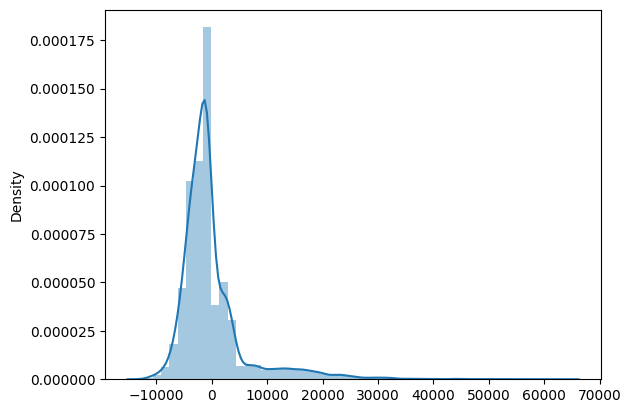

In [ ]:
import seaborn as sns

sns.distplot(lin_reg.resid)
plt.show()

From the graph we infer that due to the high value of Jarque Bera test, only few residuals are normally distributed


**Asssumption 3 - Linearity of residuals**


Here we have 2 options. Either we can plot the observed values Vs predicted values and plot the Residual Vs predicted values and see the linearity of residuals. OR We can go for rainbow test. Let's look both of them one by one.

In [ ]:
import statsmodels.api as sm
sm.stats.diagnostic.linear_rainbow(res=lin_reg, frac=0.5)#the fraction of the data to include in the center model

(np.float64(1.0134041515451815), np.float64(0.32695880118244813))

H0:The data is linear, pvalue > 0.05 failed to reject H0, here we failed to reject H0 so residuals are normally distributed

In [ ]:
lin_reg.resid.mean()

np.float64(1.6639463461565195e-09)

Assumption 4 - Homoscedasticity_test(using goldfeld test) OR (Beusch-Wagon Test) Homoscedacity :: If the variance of the residuals are symmetrically distributed across the regression line , then the data is said to homoscedastic.

Heteroscedacity :: If the variance is unequal for the residuals across the regression line, then the data is said to be heteroscedastic. In this case the residuals can form an arrow shape or any other non symmetrical shape.

This test is based on the hytpothesis testing where null and alternate hypothesis are: 𝐻0:𝜎𝑢𝑖 𝑖𝑠 𝑐𝑜𝑛𝑠𝑡𝑎𝑛𝑡 𝑎𝑐𝑟𝑜𝑠𝑠 𝑡ℎ𝑒 𝑟𝑎𝑛𝑔𝑒 𝑜𝑓 𝑑𝑎𝑡𝑎 𝐻𝑎:𝜎𝑢𝑖 𝑖𝑠 𝑛𝑜𝑡 𝑐𝑜𝑛𝑠𝑡𝑎𝑛𝑡 𝑎𝑐𝑟𝑜𝑠𝑠 𝑡ℎ𝑒 𝑟𝑎𝑛𝑔𝑒 𝑜𝑓 𝑑𝑎𝑡𝑎 The residuals should be homoscedastic.

**Goldfeld Test**

In [ ]:
import statsmodels.stats.api as sms

name=['F-statistic','p-value']
test=sms.het_goldfeldquandt(lin_reg.resid,lin_reg.model.exog)

test

(np.float64(1.2260504644104495),
 np.float64(4.111052537769733e-12),
 'increasing')

p-value below a certain level (like 0.05) indicates we should reject the null in favor of heteroscedasticity.


**Assumption 5- NO MULTI COLLINEARITY**


The interpretation of VIF is as follows: the square root of a given variable’s VIF shows how much larger the standard error is, compared with what it would be if that predictor were uncorrelated with the other features in the model. If no features are correlated, then all values for VIF will be 1.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = [variance_inflation_factor(X_constant.values, i) for i in range(X_constant.shape[1])]
pd.DataFrame({'vif': vif[1:]}, index=X.columns)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,vif
Income,3.189500
Monthly Premium Auto,27.603267
Months Since Last Claim,1.012982
Months Since Policy Inception,1.023126
Total Claim Amount,4.404303
...,...
Months_8,1.058734
Months_9,1.062184
Months_10,1.072514
Months_11,1.065476


we can see that there is high VIF in column Policy & policy type Also we have seen in statistical approach these veriables are not significant to predict target hence from above 2 conclusion we can remove them

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
X=dfn.drop(['CLV','Policy Type_Personal Auto','Policy Type_Special Auto','Policy_Personal L1','Policy_Personal L2','Policy_Personal L3',
'Policy_Special L1','Policy_Special L2','Policy_Special L3'],axis=1)
y=dfn['CLV']
y =np.log(y)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

In [ ]:
numerical_cols.rename(columns={'CLV':'CLV'},inplace=True)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(6393, 53)
(6393,)
(2741, 53)
(2741,)


**Model Building**

**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
model = lr.fit(X_train,y_train)
print(f'R^2 score for train: {lr.score(X_train, y_train)}')
print(f'R^2 score for test: {lr.score(X_test, y_test)}')

R^2 score for train: 0.2616538567159217
R^2 score for test: 0.25497363360462066


In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print("MAE",mean_absolute_error(y_test,y_pred))
print('R-squared:',r2_score(y_test,y_pred))

RMSE: 0.5771802746843294
MAE 0.4453171740148477
R-squared: 0.25497363360462066


In [ ]:
#Feature Selection by Recursive Backward Elimination
cols = list(X.columns)
pmax = 1
while (len(cols)>0):
    p= []
    X_temp = X[cols] # Use a temporary variable to avoid modifying the original X in place
    # Convert boolean columns to integers (0 and 1) for statsmodels
    X_temp = X_temp.astype(int, errors='ignore')
    Xc = sm.add_constant(X_temp)
    model = sm.OLS(y,Xc).fit()
    p = pd.Series(model.pvalues.values[1:],index = cols)
    pmax = max(p)
    feature_with_p_max = p.idxmax()
    if(pmax>0.05):
        cols.remove(feature_with_p_max)
    else:
        break
selected_features = cols
print(selected_features)

['Monthly Premium Auto', 'Number of Open Complaints', 'Number of Policies', 'Coverage_Extended', 'Coverage_Premium', 'Education_High School or Below', 'EmploymentStatus_Employed', 'Marital Status_Single', 'Policy_Corporate L2', 'Renew Offer Type_Offer2', 'Renew Offer Type_Offer3', 'Renew Offer Type_Offer4', 'Vehicle Class_SUV', 'Vehicle Class_Sports Car']


In [ ]:
X_new = X[['Monthly Premium Auto', 'Number of Open Complaints', 'Number of Policies', 'Coverage_Extended', 'Coverage_Premium', 'Education_High School or Below', 'EmploymentStatus_Employed', 'Marital Status_Single', 'Policy_Corporate L2', 'Renew Offer Type_Offer2', 'Renew Offer Type_Offer3', 'Renew Offer Type_Offer4', 'Vehicle Class_SUV', 'Vehicle Class_Sports Car']]
X_new = X_new.astype(int, errors='ignore')
X_constant_new=sm.add_constant(X_new)
lin_reg=sm.OLS(y,X_constant_new).fit()
lin_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CLV   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     228.2
Date:                Sat, 21 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:38:13   Log-Likelihood:                -7694.3
No. Observations:                9134   AIC:                         1.542e+04
Df Residuals:                    9119   BIC:                         1.553e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              7.9001      0.024    333.289      0.000       7.854       7.947
Monthly Premium Auto               0.0070      0.000     30.864      0.000       0.007       0.007
Number of Open Complaints         -0.0317      0.006     -4.895      0.000      -0.044      -0.019
Number of Policies                 0.0529      0.002     21.385      0.000       0.048       0.058
Coverage_Extended                  0.0669      0.014      4.773      0.000       0.039       0.094
Coverage_Premium                   0.0898      0.024      3.729      0.000       0.043       0.137
Education_High School or Below     0.0336      0.013      2.567      0.010       0.008       0.059
EmploymentStatus_Employed          0.0922      0.013      7.093      0.000       0.067       0.118
Marital Status_Single             -0.0506      0.014     -3.622      0.000      -0.078      -0.023
Policy_Corporate L2               -0.0548      0.024     -2.295      0.022      -0.102      -0.008
Renew Offer Type_Offer2           -0.1199      0.014     -8.370      0.000      -0.148      -0.092
Renew Offer Type_Offer3           -0.0602      0.018     -3.416      0.001      -0.095      -0.026
Renew Offer Type_Offer4           -0.1327      0.020     -6.541      0.000      -0.172      -0.093
Vehicle Class_SUV                  0.1502      0.017      8.777      0.000       0.117       0.184
Vehicle Class_Sports Car           0.1510      0.028      5.429      0.000       0.096       0.205
==============================================================================
Omnibus:                     1476.101   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2293.969
Skew:                           1.163   Prob(JB):                         0.00
Kurtosis:                       3.788   Cond. No.                         516.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Rigde and Lasso Regression**

In [ ]:
from sklearn.linear_model import Ridge, Lasso

ridge=Ridge(alpha=0.1)
ridge.fit(X_train,y_train)
print('Ridge Regression')
y_pred = ridge.predict(X_test)
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R-squared:',r2_score(y_test,y_pred))

Ridge Regression
RMSE: 0.5771785904387087
R-squared: 0.25497798165883934


In [ ]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
print('Ridge Regression')
y_pred = ridge.predict(X_test)
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R-squared:',r2_score(y_test,y_pred))

Ridge Regression
RMSE: 0.5771648851971962
R-squared: 0.25501336268521413


In [ ]:
lasso = Lasso(random_state=1)
lasso.fit(X_train,y_train)
print('Ridge Regression')
y_pred = lasso.predict(X_test)
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R-squared:',r2_score(y_test,y_pred))

Ridge Regression
RMSE: 0.5992937645386806
R-squared: 0.19679167777854611


**Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=1)

dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print("MAE",mean_absolute_error(y_test,y_pred))
print('R-squared:',r2_score(y_test,y_pred))

RMSE: 0.2678964784823966
MAE 0.10594215235380605
R-squared: 0.8394971711448858


In [ ]:
from sklearn.model_selection import train_test_split
X=dfn.drop(['CLV','Policy Type_Personal Auto','Policy Type_Special Auto','Policy_Personal L1','Policy_Personal L2','Policy_Personal L3',
'Policy_Special L1','Policy_Special L2','Policy_Special L3'],axis=1)
y=np.log(dfn['CLV'])
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

**RandomForest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=1)

rf.fit(X_train,y_train)

y_pred=rf.predict(X_test)
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print("MAE",mean_absolute_error(y_test,y_pred))
print('R-squared:',r2_score(y_test,y_pred))

RMSE: 0.19623768992176285
MAE 0.0890795302336024
R-squared: 0.913878114949403


**Hyperparameter tuning of random forest**

In [119]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

params = {
    'max_depth': [10, 20, 30, None],
    'n_estimators': [50, 100, 150],
    'bootstrap': [True, False],
    'max_features': ['sqrt', 'log2']   # removed 'auto' (deprecated)
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params,
    n_iter=10,          # only test 10 combinations
    cv=3,               # reduced from 5 → faster
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X, y)

print(random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}


In [120]:
rf = RandomForestRegressor(random_state=42)

params = {
    'max_depth': [10, 20],
    'n_estimators': [100],
    'max_features': ['sqrt']
}

grid = GridSearchCV(
    rf,
    param_grid=params,
    cv=3,           # reduce folds
    n_jobs=-1
)

grid.fit(X, y)

print(grid.best_params_)


{'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}


In [121]:
rf = RandomForestRegressor(**grid.best_params_)

rf.fit(X_train,y_train)

y_pred=rf.predict(X_test)
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print("MAE",mean_absolute_error(y_test,y_pred))
print('R-squared:',r2_score(y_test,y_pred))

RMSE: 0.24576366453716375
MAE 0.13739570584594774
R-squared: 0.8649221841175604


In [123]:
from sklearn.ensemble import AdaBoostRegressor

adaboost = AdaBoostRegressor(
    RandomForestRegressor(max_depth=5,criterion='squared_error'),
    n_estimators=150
)
adaboost.fit(X_train, y_train)

AdaBoostRegressor(estimator=RandomForestRegressor(max_depth=5),
                  n_estimators=150)

In [124]:
y_pred = adaboost.predict(X_test)
print('RMSE:',np.sqrt(mean_squared_error(y_test,y_pred)))
print("MAE",mean_absolute_error(y_test,y_pred))
print('R-squared:',r2_score(y_test,y_pred))

RMSE: 0.2184964111380751
MAE 0.1317978875825103
R-squared: 0.8932329366513572


In [125]:
pd.DataFrame(rf.feature_importances_,index=X.columns,columns=['Score']).sort_values("Score",ascending=False)[:10]

,Score
Number of Policies,0.501654
Monthly Premium Auto,0.120010
Total Claim Amount,0.062565
Months Since Policy Inception,0.028842
Months Since Last Claim,0.027041
Income,0.026261
Vehicle Class_SUV,0.025208
Vehicle Class_Luxury Car,0.013591
Vehicle Class_Luxury SUV,0.012454
Coverage_Extended,0.011370


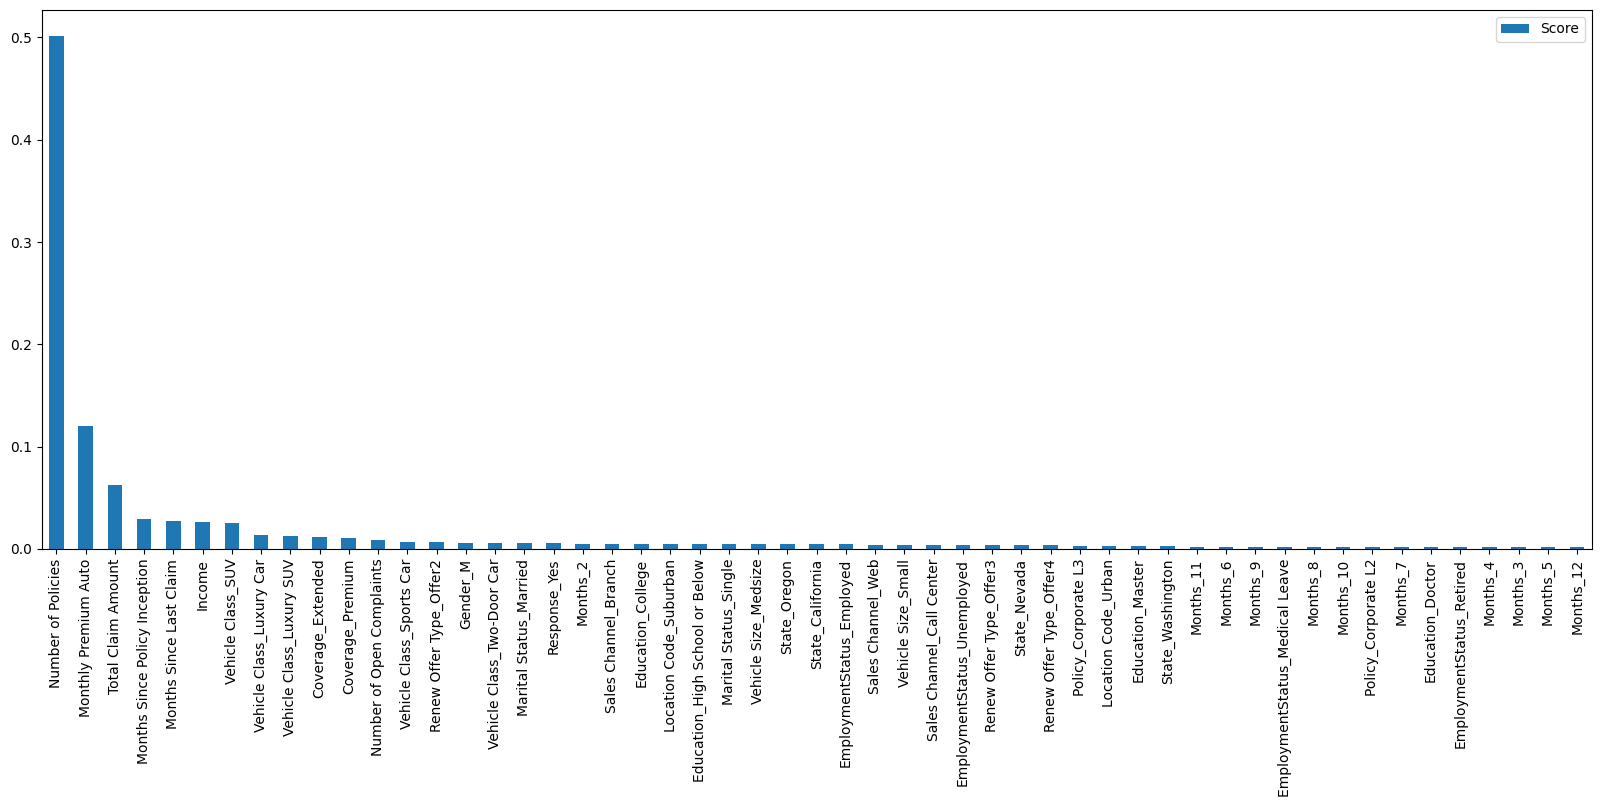

In [126]:
pd.DataFrame(rf.feature_importances_,index=X.columns,columns=['Score']).sort_values("Score",ascending=False).plot(kind='bar',figsize=(20,7))
plt.show()

Random Forest Model with hyperparameter tuning using GridSearchCV gave the best RMSE and R^2 score

No of Policies and Monthly Premium are the most important features in predicting CLV